A common issue with general LLMs is that they lack exposure to specialized medical literature or "hallucinate" when faced with technical jargon.

CPT + LoRA: By training on raw medical textbooks or clinical notes (unlabeled data), the model internalizes domain-specific terminology and factual relationships. LoRA makes this feasible by training only a fraction of the parameters.

SFT + LoRA: Once the model "knows" the facts, SFT teaches it how to use that knowledge to answer a doctor’s query or summarize a patient's history accurately.


Through this project, I gained several important insights into **domain-adaptive language model training**:

### 🔹 Importance of CPT (Continued Pretraining)

* Learned that **CPT (Continued Pretraining)** plays a crucial role in **injecting domain knowledge** into a language model.
* By further pretraining the model on **drug-related text**, the base model becomes more aligned with medical terminology and structure.
* CPT significantly improves downstream task performance compared to direct task-specific fine-tuning alone.

---

### 🔹 Fine-Tuning Phi-2 for Drug Description Generation

* Fine-tuned **Microsoft Phi-2**, a lightweight yet capable language model.
* The task was **drug description generation** given a drug name.
* Focused on producing **concise, medically relevant descriptions**.
* This project demonstrated how smaller models can still perform well with **proper domain adaptation**.

---

### 🔹 Understanding LoRA (Low-Rank Adaptation)

* Learned **LoRA in detail**, including:

  * How it reduces the number of trainable parameters
  * How it enables efficient fine-tuning on limited hardware
* Only adapter weights were trained, keeping the base model frozen.
* This made training faster and more memory-efficient while preserving model stability.

---

### 🔹 Experiment Tracking with Weights & Biases (WandB)

* Learned how to use **Weights & Biases (wandb)** for:

  * Logging training loss and evaluation metrics
  * Tracking experiments and hyperparameters
  * Comparing multiple runs efficiently
* WandB helped in better **debugging and reproducibility** of experiments.

---

## 🧠 Prompt Design for Training

The model was trained using a **structured instruction-style prompt** to clearly define the task.

### Prompt Template

```python
prompt = (
    "Given the drug name, generate a concise medical description.\n"
    f"### Drug Name: {example['Drug_Name']}\n"
    f"### Description:"
)
```

### Target / Completion Format

```python
response = " " + example["Description"]
```

### 📌 Why This Prompt Format?

* Clearly separates **instruction**, **input**, and **expected output**
* Helps the model learn a **consistent generation pattern**
* Aligns well with **instruction fine-tuning** practices
* Improves controllability and output quality

---

## 🧾 Example (Conceptual)

**Input Prompt:**

```
Given the drug name, generate a concise medical description.
### Drug Name: Paracetamol
### Description:
```

**Model Output:**

```
 Paracetamol is an analgesic and antipyretic drug commonly used to relieve mild to moderate pain and reduce fever.

```

Refer link-https://huggingface.co/Gaykar/Phi2-drug_data


In [1]:
pip install -U bitsandbytes

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd

file_path = '/content/drive/MyDrive/DrugData.csv'
work_data = pd.read_csv(file_path)
print(work_data.head())

           Drug_Name                                        Description
0            Abilify  Abilify (aripiprazole) is an atypical antipsyc...
1           Adderall  Adderall is a stimulant medication containing ...
2        Adderall XR  Adderall XR is the extended-release version of...
3         Adrenaline  Adrenaline (epinephrine) is a hormone and medi...
4  Albuterol Sulfate  Albuterol Sulfate is a bronchodilator used to ...


In [4]:
test_drug_list=work_data['Drug_Name'].tolist()
print(len(test_drug_list))

985


In [5]:
work_data.iloc[1]['Description']

'Adderall is a stimulant medication containing amphetamine and dextroamphetamine used to treat attention deficit hyperactivity disorder (ADHD) and narcolepsy by increasing attention and decreasing impulsiveness and hyperactivity.'

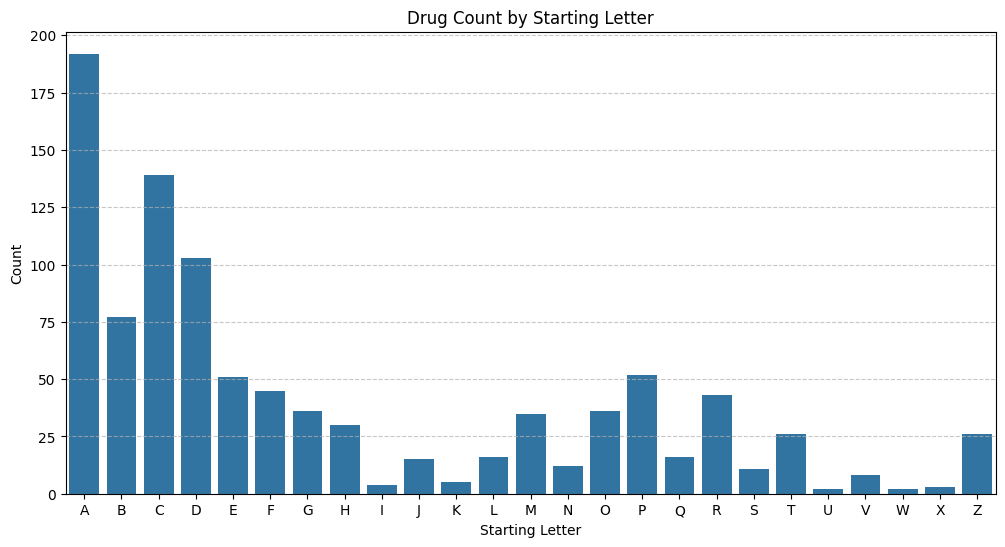

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create a new column for starting letter from the work_data DataFrame
work_data["Starting_Letter"] = work_data["Drug_Name"].str[0].str.upper()

# Plot
plt.figure(figsize=(12, 6))
sns.countplot(data=work_data, x="Starting_Letter", order=sorted(work_data["Starting_Letter"].unique()))
plt.title("Drug Count by Starting Letter")
plt.xlabel("Starting Letter")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [7]:
from datasets import Dataset
dataset=Dataset.from_pandas(work_data)
dataset

Dataset({
    features: ['Drug_Name', 'Description', 'Starting_Letter'],
    num_rows: 985
})

In [8]:
work_data['text_tokens'] = work_data['Description'].apply(lambda x: len(x.split())*1.5)

<Axes: >

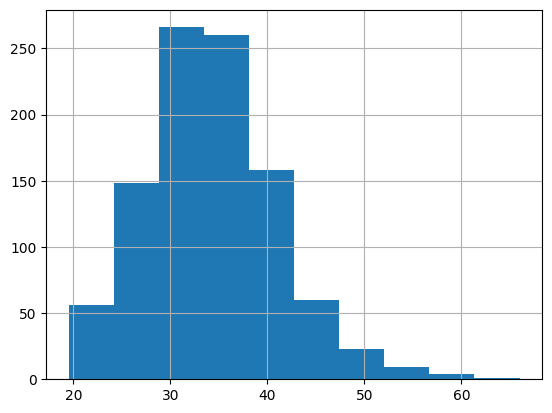

In [9]:
work_data['text_tokens'].hist()

In [10]:
def formatting_func(example):
    prompt = (
        "Given the drug name, generate a concise medical description.\n"
        f"### Drug Name: {example['Drug_Name']}\n"
        f"### Description:"
    )
    response = " " + example["Description"]
    return prompt, response



In [11]:
print(formatting_func(dataset[0]))

('Given the drug name, generate a concise medical description.\n### Drug Name: Abilify\n### Description:', ' Abilify (aripiprazole) is an atypical antipsychotic medication used to treat schizophrenia, bipolar I disorder, major depressive disorder, irritability associated with autism, and Tourette’s disorder by altering brain chemical activity affecting dopamine and serotonin.')


In [12]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_8bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)


In [13]:
base_model_id = "microsoft/phi-2"


base_model = AutoModelForCausalLM.from_pretrained(
    base_model_id,
    quantization_config=bnb_config,   # Modern API
    device_map="auto",                # Auto GPU placement
    trust_remote_code=True
)



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [14]:
from peft import LoraConfig,get_peft_model

lora_config = LoraConfig(
    r=128,
    lora_alpha=256,
    target_modules = ["Wqkv", "fc1", "fc2"]
   ,
    lora_dropout=0.001,
    bias="none",
    task_type="CAUSAL_LM"
)


In [15]:
from peft import PeftModel

model = PeftModel.from_pretrained(
    base_model,
    "/content/drive/MyDrive/phi2_cpt_checkpoints2/checkpoint-464",
    is_trainable=True
)

model.print_trainable_parameters()


trainable params: 104,857,600 || all params: 2,884,541,440 || trainable%: 3.6352


In [16]:
def print_trainable_parameters(model):
    """
    Prints the number of trainable parameters in the model.
    """
    trainable_params = 0
    all_param = 0
    for _, param in model.named_parameters():
        all_param += param.numel()
        if param.requires_grad:
            trainable_params += param.numel()
    print(
        f"trainable params: {trainable_params} || all params: {all_param} || trainable%: {100 * trainable_params / all_param}"
    )

In [17]:
print_trainable_parameters(model)

trainable params: 104857600 || all params: 2884541440 || trainable%: 3.6351566507569397


In [18]:
tokenizer = AutoTokenizer.from_pretrained(
    "/content/drive/MyDrive/phi2_cpt_checkpoints2/checkpoint-464",
    padding_size='left',
    add_eos_token=True,
    add_bos_token=True,
    use_fast=False
)

In [19]:

prompt = "Generate a drug description for 'Paracetamol'"
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
outputs = model.generate(**inputs, max_new_tokens=100)
print(tokenizer.decode(outputs[0], skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Generate a drug description for 'Paracetamol' using scientific language. Paracetamol is a nonsteroidal anti-inflammatory drug (NSAID) and analgesic used to relieve mild to moderate pain and reduce fever. It is available in various forms, including tablets, capsules, and liquid.
Answer: Paracetamol is a nonsteroidal anti-inflammatory drug (NSAID) and analgesic used to alleviate mild to moderate pain and reduce fever. It is available in multiple formulations, including oral tablets, capsules, and liquid,


In [20]:
def tokenize_fn(example, max_length=120):
    prompt, response = formatting_func(example)

    # Tokenize separately
    prompt_ids = tokenizer(
        prompt,
        add_special_tokens=False
    )["input_ids"]

    response_ids = tokenizer(
        response,
        add_special_tokens=False
    )["input_ids"]

    # Combine
    input_ids = prompt_ids + response_ids

    # MASK prompt tokens
    labels = [-100] * len(prompt_ids) + response_ids

    # Truncate
    input_ids = input_ids[:max_length]
    labels = labels[:max_length]

    # Pad
    pad_len = max_length - len(input_ids)
    input_ids += [tokenizer.pad_token_id] * pad_len
    labels += [-100] * pad_len

    attention_mask = [
        1 if token != tokenizer.pad_token_id else 0
        for token in input_ids
    ]

    return {
        "input_ids": input_ids,
        "labels": labels,
        "attention_mask": attention_mask
    }



In [21]:
tokenizer.pad_token = tokenizer.eos_token
tokenized_dataset = dataset.map(
    tokenize_fn,
    remove_columns=dataset.column_names
)

Map:   0%|          | 0/985 [00:00<?, ? examples/s]

In [22]:
print(tokenized_dataset[0])

{'input_ids': [15056, 262, 2563, 1438, 11, 7716, 257, 35327, 3315, 6764, 13, 198, 21017, 11095, 6530, 25, 2275, 346, 1958, 198, 21017, 12489, 25, 2275, 346, 1958, 357, 283, 541, 541, 3247, 2305, 8, 318, 281, 379, 4464, 605, 32867, 2924, 6210, 14103, 973, 284, 2190, 22794, 11, 31170, 314, 8967, 11, 1688, 36568, 8967, 11, 14709, 1799, 3917, 351, 15998, 11, 290, 23359, 42908, 447, 247, 82, 8967, 416, 29057, 3632, 5931, 3842, 13891, 26252, 290, 32236, 13, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256], 'labels': [-100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, 2275, 346, 1958, 357, 283, 541, 541, 3247, 2305, 8, 318, 281, 379, 4464, 605, 32867, 2924, 6210, 141

In [23]:
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling
)

In [24]:
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

In [25]:
checkpoint_saving="Phi-checkpoints"

In [26]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir=f"./{checkpoint_saving}",
    per_device_train_batch_size=4,
    gradient_accumulation_steps=1,
    lr_scheduler_type="linear",
    warmup_ratio=0.06,
    weight_decay=0.0001,
    max_grad_norm = 1.0,


    learning_rate=2e-5,
    num_train_epochs=6,
    fp16=True,
    logging_steps=10,
    save_steps=50,
    save_total_limit=2,
    optim="paged_adamw_8bit",
    report_to="wandb",
    run_name="CPT+SFT-3"
)

In [27]:
from accelerate import Accelerator

accelerator = Accelerator(gradient_accumulation_steps=1)

model = accelerator.prepare_model(model)

In [28]:
import wandb

wandb.init(
    project="phi2-drug-lora",
    name="sft+cpt-2",
    config={
        "model": "microsoft/phi-2",
        "lr_scheduler_type":"linear",
        "warmup_ratio" :0.06,
        "batch_size": 4,
        "grad_accum": 1,
        "weight_decay":0.0001,
        "max_grad_norm" : 1.0,
        "learning_rate": 2e-5,
        "epochs": 6,
        "optimizer": "paged_adamw_8bit",
        "lora": True
    }
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: bt24csh047 (bt24csh047-indian-institute-of-information-technology-nagpur) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [29]:
wandb.config.update({
    "lora_r": 64,
    "lora_alpha": 128,
    "lora_dropout": 0.01,
    "lora_target_modules": [

    "gate_proj",
    "up_proj",
    "down_proj"

    ]
}, allow_val_change=True)


In [30]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator
)

/tmp/ipython-input-507548412.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [31]:
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 50256}.
/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


Step,Training Loss
10,1.376000
20,1.150100
30,0.808500
40,0.717500
50,0.496500
60,0.503800
70,0.464100
80,0.417600
90,0.402200
100,0.463800


/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during q

Step,Training Loss
10,1.376000
20,1.150100
30,0.808500
40,0.717500
50,0.496500
60,0.503800
70,0.464100
80,0.417600
90,0.402200
100,0.463800


KeyboardInterrupt: 

In [32]:
stop///

SyntaxError: invalid syntax (ipython-input-879493578.py, line 1)

In [33]:
wandb.config.update({
    "batch_size": 4,
    "grad_accum": 1,
    "effective_batch_size": 4 * 1,
    "epochs": 6
})


In [34]:
wandb.finish()


train/epoch,▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇████
train/global_step,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇██
train/grad_norm,▄▄▄▄▄▃█▂▂▃▃▄▁▃▅▃▃▅▁▃▂▆▃▃▃▃▂▄▃▄▃▁▃▂▂▂▄▂▆▄
train/learning_rate,▁▂▆▇████▇▇▇▇▇▇▇▆▅▅▅▅▅▅▅▄▄▄▄▄▄▄▃▃▃▃▃▂▂▂▁▁
train/loss,█▄▃▄▃▄▃▄▃▂▃▃▃▂▂▂▂▂▂▃▃▂▂▂▂▂▁▂▂▂▂▂▁▂▂▁▂▁▁▁
train/epoch,4.21053
train/global_step,1040
train/grad_norm,2.13862
train/learning_rate,1e-05
train/loss,0.2755


In [ ]:
//Stop

In [36]:
import torch
base_model = AutoModelForCausalLM.from_pretrained(
    base_model_id,
    trust_remote_code=True,
    load_in_8bit=True,
    torch_dtype=torch.float16
)



The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [37]:
eval_tokenizer = AutoTokenizer.from_pretrained(
    "/content/Phi-checkpoints/checkpoint-1000",
    trust_remote_code=True,
    use_fast=False
)
eval_tokenizer.pad_token = eval_tokenizer.eos_token


In [39]:
from peft import PeftModel

ft_model = PeftModel.from_pretrained(base_model, '/content/Phi-checkpoints/checkpoint-1000')

/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


In [41]:
import os

In [42]:
clean_export_dir = "/content/drive/MyDrive/drugdataphi"

ft_model.save_pretrained(clean_export_dir)
eval_tokenizer.save_pretrained(clean_export_dir)

print(os.listdir(clean_export_dir))


['README.md', 'adapter_model.safetensors', 'adapter_config.json', 'tokenizer_config.json', 'special_tokens_map.json', 'added_tokens.json', 'vocab.json', 'merges.txt']


In [50]:
from huggingface_hub import login, upload_folder

# Login (will prompt for token)
login()

# Upload the model directory to Hugging Face Hub
upload_folder(
    folder_path="/content/drive/MyDrive/drugdataphi",
    repo_id="Gaykar/Phi2-drug_data",
    repo_type="model"
)


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   0%|          |  557kB /  419MB            

CommitInfo(commit_url='https://huggingface.co/Gaykar/Phi2-drug_data/commit/eae63d86615bc4938b77b73258e397aeff6ba843', commit_message='Upload folder using huggingface_hub', commit_description='', oid='eae63d86615bc4938b77b73258e397aeff6ba843', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Gaykar/Phi2-drug_data', endpoint='https://huggingface.co', repo_type='model', repo_id='Gaykar/Phi2-drug_data'), pr_revision=None, pr_num=None)

In [51]:
import random
import torch

# ----------------------------
# Configuration
# ----------------------------
NUM_SAMPLES = 25

# Make sure model is in eval mode
ft_model.eval()

# Pick random drugs
sample_drugs = ["Anvip","Paracetamol"]

for drug_name in sample_drugs:

    # ----------------------------
    # Build evaluation prompt
    # ----------------------------
    eval_prompt = (
        "Generate exactly ONE sentence describing the drug.\n"
        "Do not include headings or extra information.\n\n"
        f"Drug Name: {drug_name}\n"
        "Description:"
    )

    # ----------------------------
    # Tokenize prompt
    # ----------------------------
    model_input = eval_tokenizer(
        eval_prompt,
        return_tensors="pt"
    ).to(ft_model.device)

    # ----------------------------
    # Model inference (GREEDY)
    # ----------------------------
    with torch.no_grad():
        output = ft_model.generate(
            **model_input,
            do_sample=False,
            num_beams=1,# Greedy decoding
            max_new_tokens=120,
            repetition_penalty=1.1,
            eos_token_id=eval_tokenizer.eos_token_id
        )

    # ----------------------------
    # Remove prompt tokens
    # ----------------------------
    prompt_length = model_input["input_ids"].shape[1]
    generated_tokens = output[0][prompt_length:]

    # ----------------------------
    # Decode ONLY generated text
    # ----------------------------
    generated_text = eval_tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True
    ).strip()

    # ----------------------------
    # Optional: force single sentence
    # ----------------------------
    if "." in generated_text:
        generated_text = generated_text.split(".")[0] + "."

    # ----------------------------
    # Clean output
    # ----------------------------
    print("=" * 70)
    print(f"🧪 DRUG NAME (EVAL): {drug_name}\n")
    print("🤖 MODEL GENERATED DESCRIPTION:")
    print(generated_text)
    print("=" * 70)
    print()


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


🧪 DRUG NAME (EVAL): Anvip

🤖 MODEL GENERATED DESCRIPTION:
Anvip (dalfampridine extended-release) is a potassium channel blocker used to improve walking in adults with multiple sclerosis (MS).

🧪 DRUG NAME (EVAL): Paracetamol

🤖 MODEL GENERATED DESCRIPTION:
Paracetamol (acetaminophen) is a non-narcotic analgesic and antipyretic used to relieve mild to moderate pain and reduce fever.



In [48]:
import shutil
import os

source_path = '/content/Phi-checkpoints/checkpoint-1000'
destination_path = '/content/drive/MyDrive/phi-model'

# Create the destination directory if it doesn't exist
if not os.path.exists(destination_path):
    os.makedirs(destination_path)

# Copy the contents of the source directory to the destination
# If the destination directory exists and is not empty, copytree will raise an error.
# So, we ensure it's either new or handled correctly. For simplicity here,
# we'll assume it's a new copy or handle existing contents by overwriting.
# A safer approach might be to remove it first if it exists, or rename the new folder.

# To avoid errors if the destination already exists with content, we can remove it first
if os.path.exists(destination_path):
    print(f"Removing existing directory: {destination_path}")
    shutil.rmtree(destination_path)

shutil.copytree(source_path, destination_path)

print(f"Checkpoint saved to: {destination_path}")

Removing existing directory: /content/drive/MyDrive/phi-model
Checkpoint saved to: /content/drive/MyDrive/phi-model


In [ ]:
import google.generativeai as genai
from google.colab import userdata

api_key = userdata.get("GEMINI_API_KEY")
if not api_key:
    raise ValueError("GEMINI_API_KEY not found")

genai.configure(api_key=api_key)

judge_model = genai.GenerativeModel(
    "gemini-2.5-flash",
    generation_config={
        "temperature": 0.0,
        "max_output_tokens": 5
    }
)

print("✅ Gemini judge ready")




In [ ]:
import random

import random
import wandb
import google.generativeai as genai

def llm_as_judge(model, judge_model, test_drug_list, numsamples=50):
    """
    Evaluate a model using Gemini as a strict judge.

    model         : fine-tuned LLM (must have generate(prompt) method)
    judge_model   : Gemini GenerativeModel instance
    test_drug_list: list of dicts with keys ['prompt', 'expected']
    numsamples    : number of random samples to evaluate
    """

    # 1️⃣ Sample data
    samples = random.sample(
        test_drug_list,
        min(numsamples, len(test_drug_list))
    )

    yes_count, no_count = 0, 0

    # 2️⃣ Evaluation loop
    for sample in samples:
        prompt = sample["prompt"]
        expected = sample["expected"]

        # Generate model answer
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
        outputs = model.generate(**inputs, max_new_tokens=128)
        model_answer = tokenizer.decode(outputs[0], skip_special_tokens=True)


        # Build Gemini judge prompt
        judge_prompt = f"""
You are a strict evaluator.

Task:
Decide whether the Model Answer correctly answers the Question
according to the Expected Answer.

Question:
{prompt}

Expected Answer:
{expected}

Model Answer:
{model_answer}

Evaluation rules:
- Judge factual correctness and meaning, not exact wording.
- If the Model Answer is missing key information, answer No.
- If the Model Answer contradicts the Expected Answer, answer No.
- If the Model Answer is correct and sufficient, answer Yes.

Output format:
Reply with only one word: Yes or No.
"""

        # Gemini judgment
        response = judge_model.generate_content(judge_prompt)
        verdict = response.text.strip().lower()

        if verdict.startswith("yes"):
            yes_count += 1
        else:
            no_count += 1

    total = yes_count + no_count
    accuracy = yes_count / total if total > 0 else 0.0



    # 4️⃣ Return detailed results
    return {
        "accuracy": accuracy,
        "yes": yes_count,
        "no": no_count,
        "total": total
    }



In [ ]:
# Make sure Gemini is configured
judge_model = genai.GenerativeModel(
    "gemini-2.5-flash",
    generation_config={
        "temperature": 0.0,
        "max_output_tokens": 5
    }
)

print("✅ Gemini judge ready")

# Prepare the test data in the format expected by llm_as_judge
# This involves creating a list of dictionaries, each with 'prompt' and 'expected' keys.
formatted_test_data = []
for index, row in work_data.iterrows():
    # The prompt given to the fine-tuned model for generation
    input_prompt = (
        "Given the drug name, generate a concise  medical description.\n"
        f"### Drug Name: {row['Drug_Name']}\n"
        f"### Description:"
    )
    # The expected answer (ground truth description) for evaluation
    expected_answer = row['Description']
    formatted_test_data.append({
        "prompt": input_prompt,
        "expected": expected_answer
    })

results = llm_as_judge(
    model=ft_model,
    judge_model=judge_model,
    test_drug_list=formatted_test_data, # Use the newly formatted data
    numsamples=3
)

print(results)